In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#algorithms for classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

## Classification Evaluation
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.metrics import classification_report


In [2]:
data=pd.read_csv("Customer_ML_Practice_20000.csv")
data

,Age,Tenure_Months,Monthly_Usage_Hours,Support_Tickets,Satisfaction_Score,Monthly_Charges,Data_Usage_GB,Payment_Delay_Days,Contract_Months,Avg_Login_Days,Service_Count,Discount_Percent,Annual_Value,Churn
0,56,60,24.4,3,5.4,134.50,30.6,17.3,6,24.0,6,17.1,3861.87,0
1,69,18,40.0,3,9.5,76.28,42.9,4.9,12,25.6,6,24.4,2741.80,0
2,46,1,53.5,3,5.3,55.34,64.9,2.1,1,22.0,6,10.3,2253.23,1
3,32,14,39.7,1,6.2,85.16,73.4,3.8,12,24.8,1,15.9,1736.12,0
4,60,8,45.4,4,4.5,61.39,29.8,2.7,12,6.4,4,7.6,1840.49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,43,108,16.7,6,5.8,56.16,84.6,0.0,12,24.4,2,8.8,3056.84,1
19996,48,90,12.9,0,8.4,65.82,82.6,10.5,1,19.5,2,11.7,2753.05,0
19997,49,119,57.8,2,5.4,54.29,49.4,6.9,12,28.1,3,9.0,3152.64,0
19998,38,38,34.5,4,6.3,110.99,55.5,16.7,12,14.8,4,9.7,2855.78,0


In [3]:
ind=data.iloc[:,0:12]
dep=data.iloc[:,-1]

In [4]:
ind.head()

,Age,Tenure_Months,Monthly_Usage_Hours,Support_Tickets,Satisfaction_Score,Monthly_Charges,Data_Usage_GB,Payment_Delay_Days,Contract_Months,Avg_Login_Days,Service_Count,Discount_Percent
0,56,60,24.4,3,5.4,134.50,30.6,17.3,6,24.0,6,17.1
1,69,18,40.0,3,9.5,76.28,42.9,4.9,12,25.6,6,24.4
2,46,1,53.5,3,5.3,55.34,64.9,2.1,1,22.0,6,10.3
3,32,14,39.7,1,6.2,85.16,73.4,3.8,12,24.8,1,15.9
4,60,8,45.4,4,4.5,61.39,29.8,2.7,12,6.4,4,7.6


In [5]:
#split train and test data
ind_train, ind_test, dep_train, dep_test = train_test_split(
    ind,
    dep,
    test_size=0.2,
    random_state=42
)

print(ind_train.shape)
print(ind_test.shape)
print(dep_train.shape)
print(dep_test.shape)

(16000, 12)
(4000, 12)
(16000,)
(4000,)


In [6]:
sc = StandardScaler()

ind_train_scaled = sc.fit_transform(ind_train)

ind_test_scaled = sc.transform(ind_test)

In [7]:
ind = data.drop(["Churn", "Annual_Value"], axis=1)
dep= data["Churn"]

In [8]:
print(ind.columns)

Index(['Age', 'Tenure_Months', 'Monthly_Usage_Hours', 'Support_Tickets',
       'Satisfaction_Score', 'Monthly_Charges', 'Data_Usage_GB',
       'Payment_Delay_Days', 'Contract_Months', 'Avg_Login_Days',
       'Service_Count', 'Discount_Percent'],
      dtype='str')


In [9]:
print(ind.shape)

(20000, 12)


In [10]:
model1 = SVC(
    kernel="rbf",
    random_state=20
)

model1.fit(ind_train_scaled, dep_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",20
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [11]:
predict1 = model1.predict(ind_test_scaled)

print("SVM Accuracy:",
      accuracy_score(dep_test, predict1))

SVM Accuracy: 0.69475


In [12]:
model2=RandomForestClassifier(n_estimators=100,random_state=40)
model2.fit(ind_train,dep_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",40
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [13]:
predict=model2.predict(ind_test)
predict

array([0, 1, 0, ..., 0, 0, 1], shape=(4000,))

In [14]:
model3=DecisionTreeClassifier(criterion='gini',random_state=20)
model3.fit(ind_train,dep_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [15]:
predict=model3.predict(ind_test)
predict

array([1, 1, 1, ..., 0, 1, 0], shape=(4000,))

In [16]:
model4 = LogisticRegression(
    max_iter=1000
)

model4.fit(ind_train_scaled, dep_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [17]:
predict=model4.predict(ind_test_scaled)
predict

array([0, 1, 0, ..., 0, 0, 0], shape=(4000,))

In [18]:
confusion_matrix=confusion_matrix(dep_test,predict)
confusion_matrix

array([[2183,  386],
       [ 824,  607]])

In [19]:
print("SVM features:", model1.n_features_in_)
print("Random Forest features:", model2.n_features_in_)
print("Decision Tree features:", model3.n_features_in_)
print("Logistic Regression features:", model4.n_features_in_)

SVM features: 12
Random Forest features: 12
Decision Tree features: 12
Logistic Regression features: 12


<Axes: >

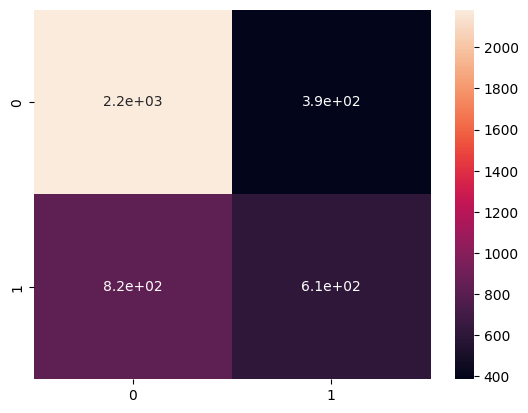

In [20]:
sns.heatmap(confusion_matrix,annot=True)

In [21]:
acc=accuracy_score(dep_test,predict)
acc

0.6975

In [22]:
#getting input
ind.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  20000 non-null  int64  
 1   Tenure_Months        20000 non-null  int64  
 2   Monthly_Usage_Hours  20000 non-null  float64
 3   Support_Tickets      20000 non-null  int64  
 4   Satisfaction_Score   20000 non-null  float64
 5   Monthly_Charges      20000 non-null  float64
 6   Data_Usage_GB        20000 non-null  float64
 7   Payment_Delay_Days   20000 non-null  float64
 8   Contract_Months      20000 non-null  int64  
 9   Avg_Login_Days       20000 non-null  float64
 10  Service_Count        20000 non-null  int64  
 11  Discount_Percent     20000 non-null  float64
dtypes: float64(7), int64(5)
memory usage: 1.8 MB


In [23]:
Age=int(input("Enter the Age:"))
Tenure_Months=int(input("Enter the Tenure_Months:"))
Monthly_Usage_Hours=float(input("Enter the Monthly_Usage_Hours:"))
Support_Tickets=int(input("Enter the Support_Tickets:"))
Satisfaction_Score=float(input("Enter the Satisfaction_Score:"))
Monthly_Charges =float(input("Enter the Monthly_Charges:"))
Data_Usage_GB =float(input("Enter the Data_Usage_GB:"))
Payment_Delay_Days =float(input("Enter the Payment_Delay_Days:"))
Contract_Months =int(input("Enter the Contract_Months:"))
Avg_Login_Days =float(input("Enter the Avg_Login_Days:"))
Service_Count =int(input("Enter the Service_Count:"))
Discount_Percent =float(input("Enter the Discount_Percent:"))


user_input = [[
    Age,
    Tenure_Months,
    Monthly_Usage_Hours,
    Support_Tickets,
    Satisfaction_Score,
    Monthly_Charges,
    Data_Usage_GB,
    Payment_Delay_Days,
    Contract_Months,
    Avg_Login_Days,
    Service_Count,
    Discount_Percent
    
]]
user_input_scaled = sc.transform(user_input)

result1 = model1.predict(user_input_scaled)
result2 = model2.predict(user_input)
result3 = model3.predict(user_input)
result4 = model4.predict(user_input_scaled)
print("\n----- PREDICTION RESULTS -----")

print("Decision Tree       :", result1[0])
print("Random Forest       :", result2[0])
print("SVM                 :", result3[0])
print("Logistic Regression :", result4[0])



ValueError: invalid literal for int() with base 10: ''

In [ ]:
import pickle

pickle.dump(model1, open("model1.pkl", "wb"))
pickle.dump(model2, open("model2.pkl", "wb"))
pickle.dump(model3, open("model3.pkl", "wb"))
pickle.dump(model4, open("model4.pkl", "wb"))

pickle.dump(sc, open("scaler.pkl", "wb"))

print("All models saved successfully!")

All models saved successfully!


In [ ]:
print("SVM:", model1.n_features_in_)
print("Random Forest:", model2.n_features_in_)
print("Decision Tree:", model3.n_features_in_)
print("Logistic Regression:", model4.n_features_in_)

SVM: 12
Random Forest: 12
Decision Tree: 12
Logistic Regression: 12
